# Hackathon 1, statistics.

This project illustrates the statistics part of the course LEPL1109. In the first part of the project, you will study the China water pollution by analyzing a dataset providing the water pollution levels collected from various monitoring stations across 10 major provinces in China throughout the year 2023. In the second part of the project, you will analyze a dataset containing high-frequency time-series  data collected from an industrial boiler operating in a chemical plant.

## Report content

•	Grades are granted to the members whose names are in the Jupyter notebook. If your name doesn’t appear on the top of the notebook, you’ll get a 0, even though you are in a group on Moodle.

•	The jupyter notebook must be compiled with printed results and next submitted via moodle. The absence of compiled results (or non-printed values) leads to a lower grade.

•	Do not comment your results directly into cells of code. Use instead a Markdown cell. 

•	"Dry" code or results not followed by a minimum of analysis / comments will be penalized.


## Report submission

•	Deadline, see moodle website. Submission after the deadline will not be accepted.

•	To submit your report, go to the section “APP” on Moodle and the subsection “Soumission du rapport”. You can upload your work there. Once you are sure that it is your final version, click the button “Envoyer le devoir”. It is important that you don’t forget to click on this button ! 

•	Reports that have not been uploaded through Moodle will not be corrected.


## Names and Noma of participants:

Part. 1: Arthur Backes (13512301)

Part. 2: Mortier Cyril (45342300)

Part. 3: Nathan Maboge (15992300)

Part. 4: Louis Robin (47062300)

Part. 5: Gaspard Martinussen (49572300)

Part. 6: Brieuc Paquet

# China Water Pollution 

This dataset provides  water pollution levels collected from various monitoring stations across 10 major provinces in China throughout the year 2023. The data  includes  parameters such as pH, turbidity, chemical and biological oxygen demand, nutrient levels, and heavy metal concentrations. These indicators are widely used by environmental monitoring agencies to assess water quality for ecological, human, and industrial impacts.

We will focus on the Water Quality Index. 

## 1. Basic statistics

1.a) Load the dataset 'china_water_pollution_data_hack.csv'. Convert Province, City  to categorical variables. (**0.5 pt**) 


In [308]:
import pandas as pd # import de la librairie pandas
import numpy as np 
from scipy import stats
from scipy.stats import t as t_dist, f as f_dist
from scipy.stats import poisson, exponweib, gamma
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Charger le fichier de données
data_frame = pd.read_csv("China_water_pollution/china_water_pollution_data_hack.csv")

# Mettre les colonnes provinces et city en tant que variable catégorielle
data_frame['Province'] = data_frame['Province'].astype('category')
data_frame['City'] = data_frame['City'].astype('category')

# On print le type de colonnes de chaque colonnes pour vérifier
print(data_frame.dtypes)



Province                    category
City                        category
Date                          object
Water_Temperature_C          float64
pH                           float64
Dissolved_Oxygen_mg_L        float64
Conductivity_uS_cm           float64
Turbidity_NTU                float64
Nitrate_mg_L                 float64
Nitrite_mg_L                 float64
Ammonia_N_mg_L               float64
Total_Phosphorus_mg_L        float64
Total_Nitrogen_mg_L          float64
COD_mg_L                     float64
BOD_mg_L                     float64
Heavy_Metals_Pb_ug_L         float64
Heavy_Metals_Cd_ug_L         float64
Heavy_Metals_Hg_ug_L         float64
Coliform_Count_CFU_100mL     float64
Water_Quality_Index          float64
dtype: object


1.b) Calculate the mean, variance, median, 25% and 75% quantiles of the water quality index (which ranges from 0 to 100) for all cities in the dataset. Comment your results! (**1.5 pts**)

In [ ]:
stats_par_ville = data_frame.groupby('City')['Water_Quality_Index'].agg([
    ('moyenne', 'mean'),
    ('variance', 'var'), 
    ('mediane', 'median'),
    ('quantile_25%', lambda x: x.quantile(0.25)),
    ('quantile_75%', lambda x: x.quantile(0.75)),
    ('nombre_observations', 'count')
]).round(2)

print("Statistiques détaillées par ville :")
for ville in stats_par_ville.index:
    print(f"\nVille: {ville}")
    stats_ville = stats_par_ville.loc[ville]
    print(f"Observations: {stats_ville['nombre_observations']}")
    print(f"Moyenne: {stats_ville['moyenne']}")
    print(f"Variance: {stats_ville['variance']}")
    print(f"Médiane: {stats_ville['mediane']}")
    print(f"Quantile 25%: {stats_ville['quantile_25%']}")
    print(f"Quantile 75%: {stats_ville['quantile_75%']}")

Statistiques détaillées par ville :

Ville: Beijing
  Observations: 299.0
  Moyenne: 58.88
  Variance: 24.45
  Médiane: 58.33
  Quantile 25%: 56.07
  Quantile 75%: 61.74

Ville: Chengdu
  Observations: 165.0
  Moyenne: 54.41
  Variance: 24.59
  Médiane: 54.8
  Quantile 25%: 51.39
  Quantile 75%: 57.27

Ville: Dali
  Observations: 144.0
  Moyenne: 54.18
  Variance: 31.27
  Médiane: 53.97
  Quantile 25%: 50.66
  Quantile 75%: 58.03

Ville: Guangzhou
  Observations: 146.0
  Moyenne: 58.36
  Variance: 34.34
  Médiane: 58.32
  Quantile 25%: 54.69
  Quantile 75%: 63.1

Ville: Hangzhou
  Observations: 148.0
  Moyenne: 58.94
  Variance: 30.31
  Médiane: 58.33
  Quantile 25%: 55.0
  Quantile 75%: 61.72

Ville: Jinan
  Observations: 160.0
  Moyenne: 58.73
  Variance: 24.63
  Médiane: 58.33
  Quantile 25%: 55.0
  Quantile 75%: 61.82

Ville: Kunming
  Observations: 152.0
  Moyenne: 58.75
  Variance: 24.48
  Médiane: 59.06
  Quantile 25%: 55.25
  Quantile 75%: 61.67

Ville: Luoyang
  Observations: 

Comment here:

## 2. Hypothesis tests 

2.a) Check with a Student's T test that the average water quality index is the same in Shenzhen and Dali: $$H_0: \mu_{Shenzhen} = \mu_{Dali},$$
$$H_1: \mu_{Shenzhen} \neq \mu_{Dali}.$$ 
Calculate all statistics and p-value without recourse to other functions than statistical distributions (use course's formula). Use a confidence level of 5%. Take care to comment your conclusions. Are all assumptions required to perform this test sastisfied? Which additional test do you have to do to validate your result? (**2.5 pts**)

In [310]:
#on récup les données sur les qualités de l'eau d'apres les 2 villes qu'on veut
x = data_frame.loc[data_frame['City'] == 'Shenzhen', 'Water_Quality_Index'].astype(float).values
y = data_frame.loc[data_frame['City'] == 'Dali','Water_Quality_Index'].astype(float).values


#calcul de la moyenne
m1 = x.mean()
m2 = y.mean()

#calcul de la variance
v1 = x.var(ddof=1)
v2 = y.var(ddof=1)

#nombres de valeurs qu'on a pour les villes
n1 = len(x)
n2 = len(y)

a = 0.05 #5% de confidence

#calcul de sp
sp = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))

#calcul de T
t = (m1 - m2) / (sp * np.sqrt(1/n1 + 1/n2))

#calcul du degré de liberté
df = n1 + n2 - 2

#calcul de p
p_a = 2 * (1 - t_dist.cdf(abs(t), df))

#on vérifie avec ma confidence de 5%
if p_a < a:
    print("H1, on rejete H0")
else:
    print("H0")

H1, on rejete H0


Comment here:

On voit par le student's T que les moyennes de qualité d'eau ne sont pas les mêmes dans les deux villes d'apres une confidence de 5%

On ne sait pas avant de faire le calcul si les variances sont égales, alors que c'esy u,e chose que l'on doit vérifier avant de faire la loi de Student. Il faudrait donc qu'on rajoute une loi de Ficher avant de réaliser les calculs avec la loi de Student.

2.b) 'Wuhan', 'Luoyang', 'Chengdu', 'Nanjing', 'Dali' seems to have similar (and low) water quality index. Test the assumption: $$H_0:  \mu_{Wuhan} = \mu_{Luoyang}= \mu_{Chengdu} = \mu_{Nanjing} =\mu_{Dali}.$$
**Hint**: reformulate the problem as a linear regression.

(**2 pts**)

In [311]:
# tableau pour boucler sur les villes
villes = ["Wuhan", "Luoyang", "Chengdu", "Nanjing", "Dali"]

#récup les données et crée un tableau avec tout les éléments 
groupe = []
for c in villes:
    val= data_frame.loc[data_frame["City"]==c, "Water_Quality_Index"].astype(float).values
    groupe.append(val)



n = np.array([len(g) for g in groupe])
moyenne  = np.array([g.mean() for g in groupe])
var  = np.array([g.var(ddof=1) for g in groupe])

#calcul grande moyenne (moyenne tout les éléments dans un seul grand tableau)
moyenne_global = np.mean(np.concatenate(groupe))

#calcul SSR et SSE 
SSR= np.sum(n * (moyenne - moyenne_global)**2)
SSE = np.sum((n - 1) * var)

#calcul degré liberté
n2  = len(groupe)
l = n.sum()
deg1 = n2 - 1
deg2 = l- n2

#calcul F
F_b = (SSR / deg1) / (SSE / deg2)

#calcul p
p_b= 1 - f_dist.cdf(F_b, deg1, deg2)


if p_b < a:
    print("H1, rejeter H0")
else: 
    print("H0")

H0


Comment here: 

On teste H0 : les moyennes des 5 villes (Wuhan, Luoyang, Chengdu, Nanjing, Dali) sont égales.
H1 : au moins une des moyennes est différente.

Réponses possible :
p_b < 0.05 : on rejette H0, on a H1 = diff de plus de 0.05 entre les moyennes (marge d'erreur)
p_b > 0.05 : on ne rejette pas H0

ici, on ne rejette pas H0, donc les moyennes des 5 villes sont égales.


## 3. Regressions

3.a) Propose a regression model which explains the Water_Quality_Index as a function of other explanatory variables, **for the city of Shanghai**. Split your data set into a training set (80% of the data) that you use for fitting the model and a test set (20% of the data) on which you test the accuracy of the model. 

* Use the OLS() function of the package statsmodels.api to perform the linear regression. 
* Comment your results (goodness of fit, R2, F-stat and T-stats of coefficients)
* Identify potential non-relevant covariates
* Calculate the MAE on the test and training sets. 

(**3 pts**)

In [312]:
#code here 


Comment here: 

3.b) Same question as 3.a) but now you use a Gaussian process regression. Use a RBF and Matern kernel and compare MAEs of the 2 models. Which one is the best? (**2 pts**)

In [313]:
#code here


Comment here: 

# Boiler

![furnace_plotL](boiler/furnace_plotL.PNG)

This dataset contains high-frequency time-series  data collected (every 5 seconds) from an industrial boiler operating in a chemical plant. The boiler is equipped with multiple sensors capturing parameters such as pressure, temperature, flow rate, and oxygen levels. The dataset reflects a real-world industrial scenario. The boiler outlet steam temperature, ranging typically from 530 °C to 545 °C during stable operation, is used as the key indicator of equipment state. Deviations outside this range represent abnormal operating conditions. 

## 4. Poisson Process

4. During stable operations, the outlet steam temperature is in the interval 530 °C to 545 °C. 

a) Load the dataset 'data_boiler.csv', plot the Boiler outlet steam temperature (variable 'TE_8332A.AV_0') and count the number of times this temperature is outside this normal range. What do you observe? (**1 pt**)

Nom des colonnes :  ['date', 'PT_8313A.AV_0#', 'PT_8313B.AV_0#', 'PT_8313C.AV_0#', 'PT_8313D.AV_0#', 'PT_8313E.AV_0#', 'PT_8313F.AV_0#', 'PTCA_8322A.AV_0#', 'PTCA_8324.AV_0#', 'TE_8319A.AV_0#', 'TE_8319B.AV_0#', 'TE_8313B.AV_0#', 'TE_8303.AV_0#', 'TE_8304.AV_0#', 'TV_8329ZC.AV_0#', 'FT_8301.AV_0#', 'FT_8302.AV_0#', 'FT_8306A.AV_0#', 'AIR_8301A.AV_0#', 'FT_8306B.AV_0#', 'AIR_8301B.AV_0#', 'YFJ3_AI.AV_0#', 'YFJ3_ZD1.AV_0#', 'YFJ3_ZD2.AV_0#', 'SXLTCYZ.AV_0#', 'SXLTCYY.AV_0#', 'ZCLCCY.AV_0#', 'YCLCCY.AV_0#', 'YJJWSLL.AV_0#', 'ZZQBCHLL.AV_0#', 'TE_8332A.AV_0#']
Nombre de températures anormales : 7037
Nombre total de températures mesurées : 86400
Pourcentage de températures en dehors de l'intervalle : 8.144675925925926%


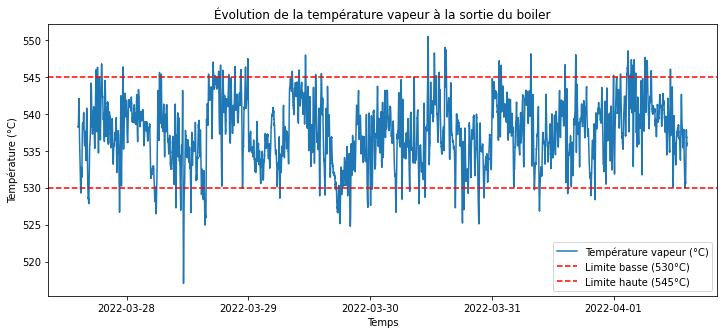

In [314]:
#code here

# Chargement du dataset
df = pd.read_csv("Boiler/data_boiler.csv")

# On vérifie le nom des colonnes ici
print("Nom des colonnes : ", df.columns.tolist())

# On convertit la colonne de date en format datetime
df['date'] = pd.to_datetime(df['date'])

# On isole la colonne de température
temp = df['TE_8332A.AV_0#']

# Définition des bornes normales
Min = 530
Max = 545

# Comptage des températures en dehors de l'intervalle
abnormal_mask = (temp < Min) | (temp > Max)
n_abnormal = abnormal_mask.sum()

# Comptage de nombre de température totale
n_total_temp = len(temp)




print(f"Nombre de températures anormales : {n_abnormal}")

print(f"Nombre total de températures mesurées : {n_total_temp}")

print(f"Pourcentage de températures en dehors de l'intervalle : {100*n_abnormal/n_total_temp}%")

# Graphe
plt.figure(figsize=(12,5))
plt.plot(df['date'], temp, label="Température vapeur (°C)")
plt.axhline(y=Min, color='r', linestyle='--', label='Limite basse (530°C)')
plt.axhline(y=Max, color='r', linestyle='--', label='Limite haute (545°C)')
plt.title("Évolution de la température vapeur à la sortie du boiler")
plt.xlabel("Temps")
plt.ylabel("Température (°C)")
plt.legend()
plt.show()


Comment here: 

b) A Poisson process, denoted by $N_t$ is a counting process. The number of events observed during an interval [0,t] is distributed according to a Poisson law with a parameter $\lambda \times t$. Using the method of moment, estimate $\lambda \times t$, the frequency of overheating **or** underheating (i.e. when we are outside the interval) per hour.

Remark: do not forget that time-series data are collected every 5 seconds.

(**1.5 pt**)

In [315]:
# Nombre total de points
n_total = len(df)

# Durée totale en heures
total_hours = (n_total * 5) / 3600

# Fréquence des anomalies (lambda)
lambda_est = n_abnormal / total_hours

print(f"Fréquence estimée λ (événements par heure) = {lambda_est:.2f}")



Fréquence estimée λ (événements par heure) = 58.64


c) Calculate the probability of observing more ( >= ) than 50 abnormal temperatures on 1h. (**1 pt**)

In [316]:
#code here

# Probabilité d'au moins 50 anomalies en 1h
p_more_50 = 1 - poisson.cdf(49, mu=lambda_est)
print(f"Probabilité d'observer ≥ 50 anomalies sur 1h = {p_more_50:.5f}")



Probabilité d'observer ≥ 50 anomalies sur 1h = 0.88582


Comment here: 

## 5. Fit of distributions and forecasting 

5. The induced draft fan motor current must in normal condition stay below 30 Amp. A current above 30 Amp may cause damage to the installation. 

a) Fit a Gamma and an exponentiated Weibull distributions to the variable YFJ3_AI.AV_0. Compare histograms and  densities, and choose the most appropriate distribution. Using the most appropriate distribution, determine the probability that over a similar period of time, we observe a peak of induced draft fan motor current above 30 Amp. 
(**3 pts**)

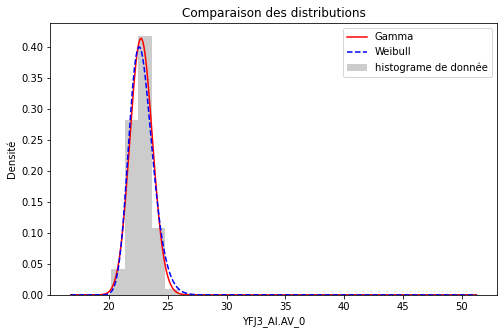

Vraisemblance log (Gamma): -119234.04
Vraisemblance log (Weibull): -120594.84
Meilleure distribution: Gamma
Probabilité > 30 A = 0.000000000003437


In [317]:
# Récupération de la colonne cible (courant moteur) en supprimant les valeurs manquantes
data = df["YFJ3_AI.AV_0#"].dropna()

# on ajuste les distribution gamma et weibull
params_gamma = gamma.fit(data, floc=0)
params_exponweib = exponweib.fit(data, floc=0)

# Faire une comparaison visuelle avec le graphique
x = np.linspace(data.min(), data.max(), 300) #300 points entre la valeur min et max des données, sert à tracer les courbes.
pdf_gamma = gamma.pdf(x, *params_gamma) # calcul la densité de proba pour chaque point x (Gamma)
pdf_exponweib = exponweib.pdf(x, *params_exponweib) # même chose pour weidbull

plt.figure(figsize=(8,5))
plt.hist(data, bins=30, density=True, alpha=0.4, color='gray', label='histograme de donnée')
plt.plot(x, pdf_gamma, 'r-', label='Gamma')
plt.plot(x, pdf_exponweib, 'b--', label='Weibull')
plt.legend()
plt.xlabel("YFJ3_AI.AV_0")
plt.ylabel("Densité")
plt.title("Comparaison des distributions")
plt.show()

# calcul des log-vraisemblance pour cherche la meilleur distribution
logL_gamma = np.sum(gamma.logpdf(data, *params_gamma))
logL_exponweib = np.sum(exponweib.logpdf(data, *params_exponweib))

print(f"Vraisemblance log (Gamma): {logL_gamma:.2f}")
print(f"Vraisemblance log (Weibull): {logL_exponweib:.2f}")

# Recherche de la meilleur distribution
if logL_gamma > logL_exponweib:
    best_dist = "Gamma"
    params_best = params_gamma
else:
    best_dist = "Weibull"
    params_best = params_exponweib

print(f"Meilleure distribution: {best_dist}")

seuil = 30

# si c'est gamma on calcul la proba de > 30 amp
if best_dist == "Gamma":
    prob_over_30 = 1 - gamma.cdf(seuil, *params_best)

# pareil mais si c'est weidbull
else:
    prob_over_30 = 1 - exponweib.cdf(seuil, *params_best)

print(f"Probabilité > 30 A = {prob_over_30:.15f}")

Comment here: 

We can see that the gamma distribution is more reliable because it's less negativ than the Weidbull distribution.
The gamma distribution is more appropriate in this context.

It's extremely rare to have +30 A, so the probability are almost 0.

b) You want to set up a prediction algorithm of over- and under-heating (variable TE_8332A.AV_0). The aim is to anticipate any abnormal deviation to take necessary measures for driving back the temperature in $[530 ; 545]$. For this purpose, you will use the measure at time $ t - lag \times 5s$ for predicting the steam temperature at time t, where $lag$ is the number of 5-seconds lags. The model to fit is of the form:
$$Y_t = \beta_0 + \beta_1 X^1_{t-lag}+\beta_2 X^2_{t-lag}+...+\beta_n X^n_{t-lag}+\varepsilon,$$ 
where $Y$ is the target variable (i.e. TE_8332A.AV_0), $(X^1,...,X^n)$ are all the explanatory variables (i.e. all the variables except TE_8332A.AV_0) and $\varepsilon \sim N(0,1).$

* Create a dataset such that for each date $t$ (each line), you have the target variable at time $t$ and the explanatory variables at time $t-lag \times 5s$.
* Use the OLS() function of the package statsmodels.api to perform the linear regression. 
* If an explanatory variable is not significant, remove it from your model.
* Test different lags and determine  the maximum number of lags, such that the probabilities that your model detects over- and under-heatings are above 90%

(**4 pts**)

In [318]:
#code here



Comment here:

c)  Compare the probabilities that your model detects over- and under-heatings. (**1 pt**)

In [319]:
#code here


Comment here: 